# Assignment 01 - Intelligent System Development

## System 2: Vietnam House Price Prediction System

**Problem type:** Regression

**Dataset source:** Kaggle - House Price Prediction Dataset Vietnam - 2024

### Objective

The purpose of this intelligent system is to estimate a property's listed price from a structured representation of its location, physical characteristics, legal status, and furnishing information.

This notebook develops and evaluates an educational machine-learning workflow. It is not a professional property valuation service.

## 1. System and Problem Definition

The Vietnam House Price Prediction System is a supervised regression system.

### Input

Structured information about a house or property.

### Representation

A combination of numerical and categorical raw features. Categorical raw features may expand into multiple encoded columns during preprocessing.

### Preprocessing

Missing numerical values are median-imputed and standardized. Missing categorical values are mode-imputed and one-hot encoded.

### Learning

A regression model learns relationships between property attributes and listed prices from historical examples.

### Output

A predicted property price in billions of Vietnamese Dong (VND), matching the dataset target unit.

### Application

The fitted Pipeline can later support a Web or Mobile interface, but no application layer is built in this notebook.

## 2. Intelligent System Diagram

```text
Property
   ↓
Property Information
   ↓
Feature Representation
   ↓
Preprocessing
   ↓
Regression Model
   ↓
Predicted House Price
   ↓
Web / Mobile Application
```

In [1]:
import os
import platform
import unicodedata
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_absolute_percentage_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
CURRENT_DIR = Path.cwd()

if (CURRENT_DIR / "data").exists():
    PROJECT_ROOT = CURRENT_DIR
elif (CURRENT_DIR.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent
elif (CURRENT_DIR.parent.parent / "data").exists():
    PROJECT_ROOT = CURRENT_DIR.parent.parent
else:
    raise FileNotFoundError("Project root not found.")

DATA_PATH = PROJECT_ROOT / "data" / "house_price" / "vietnam_housing_dataset.csv"
FIGURE_DIR = PROJECT_ROOT / "figures" / "house_price"
MODEL_DIR = PROJECT_ROOT / "models" / "house_price"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Dataset path:", DATA_PATH)
print("Dataset exists:", DATA_PATH.exists())

Project root: E:\WINDOW\Project\intelligent-system-assignment-01
Dataset path: E:\WINDOW\Project\intelligent-system-assignment-01\data\house_price\vietnam_housing_dataset.csv
Dataset exists: True


## 3. Dataset Loading and Inspection

The repository contains one House Price CSV file: `vietnam_housing_dataset.csv`. Its schema is inspected before identifying the target or selecting features.

In [3]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
df.head()

Dataset loaded successfully.


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


In [4]:
rows, columns = df.shape

print("Number of observations:", rows)
print("Number of columns:", columns)
print("\nColumns:")
for index, column in enumerate(df.columns, start=1):
    print(f"{index}. {column}")

Number of observations: 30229
Number of columns: 12

Columns:
1. Address
2. Area
3. Frontage
4. Access Road
5. House direction
6. Balcony direction
7. Floors
8. Bedrooms
9. Bathrooms
10. Legal status
11. Furniture state
12. Price


In [5]:
df.info()

print("\nData types:")
print(df.dtypes)

<class 'pandas.DataFrame'>
RangeIndex: 30229 entries, 0 to 30228
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Address            30229 non-null  str    
 1   Area               30229 non-null  float64
 2   Frontage           18665 non-null  float64
 3   Access Road        16932 non-null  float64
 4   House direction    8990 non-null   str    
 5   Balcony direction  5246 non-null   str    
 6   Floors             26626 non-null  float64
 7   Bedrooms           25067 non-null  float64
 8   Bathrooms          23155 non-null  float64
 9   Legal status       25723 non-null  str    
 10  Furniture state    16110 non-null  str    
 11  Price              30229 non-null  float64
dtypes: float64(7), str(5)
memory usage: 2.8 MB

Data types:
Address                  str
Area                 float64
Frontage             float64
Access Road          float64
House direction          str
Balcony direction       

In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Address,30229,10265,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",187,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area,30229.0,NaN,NaN,NaN,68.498741,48.069835,3.1,40.0,56.0,80.0,595.0
Frontage,18665.0,NaN,NaN,NaN,5.361692,4.346174,1.0,4.0,4.5,5.0,77.0
Access Road,16932.0,NaN,NaN,NaN,7.8538,7.451313,1.0,4.0,6.0,10.0,85.0
House direction,8990,8,Đông - Nam,1916,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Balcony direction,5246,8,Đông - Nam,1087,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Floors,26626.0,NaN,NaN,NaN,3.410426,1.328897,1.0,2.0,3.0,4.0,10.0
Bedrooms,25067.0,NaN,NaN,NaN,3.51103,1.309116,1.0,3.0,3.0,4.0,9.0
Bathrooms,23155.0,NaN,NaN,NaN,3.346837,1.400181,1.0,2.0,3.0,4.0,9.0
Legal status,25723,2,Have certificate,24774,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Dataset Description

The dataset contains 30,229 property listings and 12 original columns: 11 candidate inputs and the Price target. According to the [Kaggle dataset card](https://www.kaggle.com/datasets/nguyentiennhan/vietnam-housing-dataset-2024), Area is measured in square metres, Frontage and Access Road in metres, and Price in billions of VND.

The file already stores these measurements as numeric values, so no text-unit conversion such as parsing “tỷ”, “triệu”, or “m²” is required.

## 4. Data Quality and Cleaning

Data quality is assessed using missingness, duplicates, cardinality, numeric ranges, and categorical samples. Unusual values are investigated before any decision to remove observations.

In [7]:
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing Percentage (%)": (df.isna().mean() * 100).round(2)
})

unique_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Unique Values (including missing)": df.nunique(dropna=False)
})

print("Missing-value summary:")
print(missing_summary.to_string())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nData types and unique-value counts:")
print(unique_summary.to_string())

Missing-value summary:
                   Missing Count  Missing Percentage (%)
Address                        0                    0.00
Area                           0                    0.00
Frontage                   11564                   38.25
Access Road                13297                   43.99
House direction            21239                   70.26
Balcony direction          24983                   82.65
Floors                      3603                   11.92
Bedrooms                    5162                   17.08
Bathrooms                   7074                   23.40
Legal status                4506                   14.91
Furniture state            14119                   46.71
Price                          0                    0.00



Duplicate rows: 0

Data types and unique-value counts:
                  Data Type  Unique Values (including missing)
Address                 str                              10265
Area                float64                               1512
Frontage            float64                                408
Access Road         float64                                141
House direction         str                                  9
Balcony direction       str                                  9
Floors              float64                                 11
Bedrooms            float64                                 10
Bathrooms           float64                                 10
Legal status            str                                  3
Furniture state         str                                  3
Price               float64                                687


In [8]:
numeric_columns = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Price"
]

numeric_quality = pd.DataFrame({
    "Minimum": df[numeric_columns].min(),
    "Maximum": df[numeric_columns].max(),
    "Non-positive Count": (df[numeric_columns] <= 0).sum(),
    "Missing Count": df[numeric_columns].isna().sum()
})

integer_measurement_check = {
    column: int(((df[column].dropna() % 1) != 0).sum())
    for column in ["Floors", "Bedrooms", "Bathrooms"]
}

print("Numeric quality checks:")
print(numeric_quality.to_string())
print("\nNon-integer counts for discrete measurements:")
print(integer_measurement_check)

Numeric quality checks:
             Minimum  Maximum  Non-positive Count  Missing Count
Area             3.1    595.0                   0              0
Frontage         1.0     77.0                   0          11564
Access Road      1.0     85.0                   0          13297
Floors           1.0     10.0                   0           3603
Bedrooms         1.0      9.0                   0           5162
Bathrooms        1.0      9.0                   0           7074
Price            1.0     11.5                   0              0

Non-integer counts for discrete measurements:
{'Floors': 0, 'Bedrooms': 0, 'Bathrooms': 0}


### Data Quality Findings

- The dataset has no duplicate rows.
- Address, Area, and Price have no missing values.
- Missingness is substantial for Balcony direction (82.65%), House direction (70.26%), Furniture state (46.71%), Access Road (43.99%), and Frontage (38.25%).
- Floors, Bedrooms, Bathrooms, and Legal status have lower but still meaningful missingness.
- All observed numerical measurements and target prices are positive.
- Floors, Bedrooms, and Bathrooms contain whole-number measurements stored as floats because missing values require a nullable numeric representation.
- No row is removed at this stage. Missing values will be learned and handled inside model Pipelines.

### 4.1 Deterministic Location Extraction

Address contains useful location information but has 10,265 distinct strings, including project names, streets, wards, districts, punctuation variants, and a small number of noisy endings. Direct one-hot encoding would create an unnecessarily high-cardinality representation.

A deployable Province feature is extracted from the last comma-separated address component. Actual aliases and obvious noisy endings found during inspection are normalized explicitly. This transformation uses no target values and learns no statistics.

In [9]:
PROVINCE_ALIASES = {
    "TP. HCM": "Hồ Chí Minh",
    "TPHCM": "Hồ Chí Minh",
    "TpHCM": "Hồ Chí Minh",
    "TP Hồ Chí Minh": "Hồ Chí Minh",
    "Hồ Chí Mính": "Hồ Chí Minh",
    "Hồ Chí Minh giá 2tỷ380": "Hồ Chí Minh",
    "Quận Bình Thạnh": "Hồ Chí Minh",
    "Quận 8": "Hồ Chí Minh",
    "Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt": "Hồ Chí Minh",
    "HN": "Hà Nội",
    "Hai Bà Trưng": "Hà Nội",
    "Quận Nam Từ Liêm": "Hà Nội",
    "Bình Dương (gần cafe Xóm Vắng 2)": "Bình Dương",
    "TP. Cam Ranh": "Khánh Hòa",
    "Quảng Ninh (Ngã 3 đường Hòn Gai cũ)": "Quảng Ninh",
    "Đường số 11": "Unknown",
    "Phòng công chứng Nguyễn Thị Thành": "Unknown",
    "giá 6ty": "Unknown"
}


def extract_province(address):
    """Extract and normalize the final location component of an address."""
    if pd.isna(address):
        return np.nan

    normalized_address = unicodedata.normalize("NFC", str(address)).strip()
    components = [
        component.strip(" .")
        for component in normalized_address.split(",")
        if component.strip(" .")
    ]

    province = components[-1] if components else np.nan
    return PROVINCE_ALIASES.get(province, province)


df_clean = df.copy()
df_clean["Province"] = df_clean["Address"].apply(extract_province)

address_parsing_examples = df_clean.loc[
    [0, 3, 10, 100, 1000],
    ["Address", "Province"]
]

print("Address parsing examples:")
print(address_parsing_examples.to_string(index=False))
print("\nMissing Province values:", df_clean["Province"].isna().sum())
print("Normalized Province labels:", df_clean["Province"].nunique())

Address parsing examples:


                                                                    Address    Province
Dự án The Empire - Vinhomes Ocean Park 2, Xã Long Hưng, Văn Giang, Hưng Yên    Hưng Yên
                      Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ Chí Minh Hồ Chí Minh
 Dự án The Crown - Vinhomes Ocean Park 3, Xã Nghĩa Trụ, Văn Giang, Hưng Yên    Hưng Yên
                Đường Nguyễn Thượng Hiền, Phường 5, Bình Thạnh, Hồ Chí Minh Hồ Chí Minh
                  Đường Ấp Tam Đông, Xã Thới Tam Thôn, Hóc Môn, Hồ Chí Minh Hồ Chí Minh

Missing Province values: 0
Normalized Province labels: 60


In [10]:
cleaning_summary = pd.DataFrame({
    "Rows Before Cleaning": [len(df)],
    "Rows After Cleaning": [len(df_clean)],
    "Rows Dropped": [len(df) - len(df_clean)],
    "Duplicate Rows": [df_clean.duplicated().sum()],
    "Missing Target Values": [df_clean["Price"].isna().sum()],
    "Non-positive Target Values": [(df_clean["Price"] <= 0).sum()]
})

cleaning_summary

,Rows Before Cleaning,Rows After Cleaning,Rows Dropped,Duplicate Rows,Missing Target Values,Non-positive Target Values
0,30229,30229,0,0,0,0


### Cleaning Result

Province extraction produces 60 normalized labels and no missing Province values. Three clearly non-geographic trailing strings are retained as the explicit category “Unknown” rather than silently deleting their rows.

No observations are dropped. The numeric columns are already stored in the documented units, and all target prices are positive. Therefore, MAPE can be computed safely without division by zero. Statistical imputation and categorical encoding are intentionally postponed to the Pipeline after the train/test split.

## 5. Target and Formal Data Representation

The actual target column is **Price**, representing the listed property price in billions of VND.

This is a supervised regression problem:

- Each property is represented by a raw feature vector: x_i = [x_i1, ..., x_id].
- The target is a real-valued price: y_i ∈ R.
- The learned model produces an estimate: ŷ = fθ(x).

The target remains on its original scale. Its observed distribution is nearly symmetric, so a logarithmic target transformation is not introduced.

In [11]:
target = "Price"

print("Target:", target)
print("Target data type:", df_clean[target].dtype)
print("Target minimum:", df_clean[target].min())
print("Target maximum:", df_clean[target].max())
print("Target mean:", round(df_clean[target].mean(), 4))
print("Target median:", round(df_clean[target].median(), 4))
print("Target skewness:", round(df_clean[target].skew(), 4))
print("Zero target count:", int((df_clean[target] == 0).sum()))

Target: Price
Target data type: float64
Target minimum: 1.0
Target maximum: 11.5
Target mean: 5.8721
Target median: 5.9
Target skewness: -0.029
Zero target count: 0


## 6. Feature Analysis and Selection

The main representation must contain exactly six raw features. Selection considers real-estate relevance, missingness, interpretability, redundancy, cardinality, and whether the feature can be supplied by a future interface. It is not based only on target correlation.

In [12]:
feature_analysis = pd.DataFrame([
    {
        "Feature": "Address",
        "Type": "Categorical text",
        "Meaning": "Complete listing address",
        "Missing/Quality Observations": f"0% missing; {df_clean['Address'].nunique():,} unique strings with text noise",
        "Decision": "Not selected",
        "Reason": "Replaced by deployable Province to avoid extreme cardinality"
    },
    {
        "Feature": "Province",
        "Type": "Categorical",
        "Meaning": "Normalized province/city market",
        "Missing/Quality Observations": f"{df_clean['Province'].isna().mean() * 100:.2f}% missing; {df_clean['Province'].nunique()} labels",
        "Decision": "Selected",
        "Reason": "Location is fundamental and Province is interpretable"
    },
    {
        "Feature": "Area",
        "Type": "Numerical",
        "Meaning": "Property area in square metres",
        "Missing/Quality Observations": f"{df_clean['Area'].isna().mean() * 100:.2f}% missing; positive values",
        "Decision": "Selected",
        "Reason": "Direct, complete measure of property scale"
    },
    {
        "Feature": "Frontage",
        "Type": "Numerical",
        "Meaning": "Front width in metres",
        "Missing/Quality Observations": f"{df_clean['Frontage'].isna().mean() * 100:.2f}% missing",
        "Decision": "Not selected",
        "Reason": "Relevant but omitted from compact representation because of high missingness"
    },
    {
        "Feature": "Access Road",
        "Type": "Numerical",
        "Meaning": "Access-road width in metres",
        "Missing/Quality Observations": f"{df_clean['Access Road'].isna().mean() * 100:.2f}% missing",
        "Decision": "Not selected",
        "Reason": "Relevant but omitted from compact representation because of high missingness"
    },
    {
        "Feature": "House direction",
        "Type": "Categorical",
        "Meaning": "Direction faced by the house",
        "Missing/Quality Observations": f"{df_clean['House direction'].isna().mean() * 100:.2f}% missing",
        "Decision": "Not selected",
        "Reason": "Very high missingness"
    },
    {
        "Feature": "Balcony direction",
        "Type": "Categorical",
        "Meaning": "Direction faced by the balcony",
        "Missing/Quality Observations": f"{df_clean['Balcony direction'].isna().mean() * 100:.2f}% missing",
        "Decision": "Not selected",
        "Reason": "Highest missingness and not applicable to every property"
    },
    {
        "Feature": "Floors",
        "Type": "Numerical discrete",
        "Meaning": "Number of floors",
        "Missing/Quality Observations": f"{df_clean['Floors'].isna().mean() * 100:.2f}% missing; whole-number observations",
        "Decision": "Selected",
        "Reason": "Interpretable measure of vertical capacity"
    },
    {
        "Feature": "Bedrooms",
        "Type": "Numerical discrete",
        "Meaning": "Number of bedrooms",
        "Missing/Quality Observations": f"{df_clean['Bedrooms'].isna().mean() * 100:.2f}% missing; whole-number observations",
        "Decision": "Selected",
        "Reason": "Core capacity feature with moderate missingness"
    },
    {
        "Feature": "Bathrooms",
        "Type": "Numerical discrete",
        "Meaning": "Number of bathrooms",
        "Missing/Quality Observations": f"{df_clean['Bathrooms'].isna().mean() * 100:.2f}% missing; whole-number observations",
        "Decision": "Selected",
        "Reason": "Separate amenity/capacity information"
    },
    {
        "Feature": "Legal status",
        "Type": "Categorical",
        "Meaning": "Certificate or sale-contract status",
        "Missing/Quality Observations": f"{df_clean['Legal status'].isna().mean() * 100:.2f}% missing; low cardinality",
        "Decision": "Selected",
        "Reason": "Interpretable and more complete than several alternatives"
    },
    {
        "Feature": "Furniture state",
        "Type": "Categorical",
        "Meaning": "Basic or full furnishing state",
        "Missing/Quality Observations": f"{df_clean['Furniture state'].isna().mean() * 100:.2f}% missing",
        "Decision": "Not selected",
        "Reason": "Useful but omitted from compact representation because nearly half is missing"
    }
])

feature_analysis

,Feature,Type,Meaning,Missing/Quality Observations,Decision,Reason
0,Address,Categorical text,Complete listing address,"0% missing; 10,265 unique strings with text noise",Not selected,Replaced by deployable Province to avoid extre...
1,Province,Categorical,Normalized province/city market,0.00% missing; 60 labels,Selected,Location is fundamental and Province is interp...
2,Area,Numerical,Property area in square metres,0.00% missing; positive values,Selected,"Direct, complete measure of property scale"
3,Frontage,Numerical,Front width in metres,38.25% missing,Not selected,Relevant but omitted from compact representati...
4,Access Road,Numerical,Access-road width in metres,43.99% missing,Not selected,Relevant but omitted from compact representati...
5,House direction,Categorical,Direction faced by the house,70.26% missing,Not selected,Very high missingness
6,Balcony direction,Categorical,Direction faced by the balcony,82.65% missing,Not selected,Highest missingness and not applicable to ever...
7,Floors,Numerical discrete,Number of floors,11.92% missing; whole-number observations,Selected,Interpretable measure of vertical capacity
8,Bedrooms,Numerical discrete,Number of bedrooms,17.08% missing; whole-number observations,Selected,Core capacity feature with moderate missingness
9,Bathrooms,Numerical discrete,Number of bathrooms,23.40% missing; whole-number observations,Selected,Separate amenity/capacity information


In [13]:
selected_features = [
    "Province",
    "Area",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Legal status"
]

selected_numeric_features = [
    "Area",
    "Floors",
    "Bedrooms",
    "Bathrooms"
]

selected_categorical_features = [
    "Province",
    "Legal status"
]

print("Six selected raw features:")
for index, feature in enumerate(selected_features, start=1):
    print(f"{index}. {feature}")

print("\nTarget:", target)
assert len(selected_features) == 6
assert target not in selected_features

Six selected raw features:
1. Province
2. Area
3. Floors
4. Bedrooms
5. Bathrooms
6. Legal status

Target: Price


### Selected Six-Feature Representation

The compact representation combines:

1. Province for market location.
2. Area for property size.
3. Floors for vertical capacity.
4. Bedrooms for accommodation capacity.
5. Bathrooms for amenity capacity.
6. Legal status for ownership documentation.

Province and Legal status are two raw categorical features even though one-hot encoding later creates multiple encoded columns. A raw feature is therefore not the same as an encoded feature or a final numerical model input.

## 7. Exploratory Data Analysis

Exactly five distribution plots are used to examine the target and four important raw features. Missing numerical observations are excluded only from plotting; they are not removed from the modeling dataset.

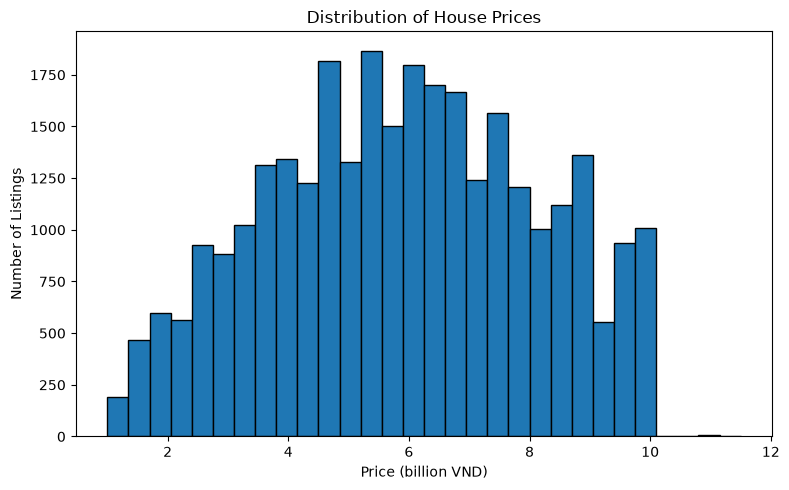

In [14]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Price"], bins=30, edgecolor="black")
plt.title("Distribution of House Prices")
plt.xlabel("Price (billion VND)")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

### Analysis - Price Distribution

Price ranges from 1.0 to 11.5 billion VND. The mean is 5.8721 and the median is 5.9 billion VND. Skewness is -0.0290, which is close to zero, so the target is approximately symmetric rather than strongly right-skewed.

Because the original-scale target is already well behaved and is easy to interpret, no logarithmic target transformation is applied.

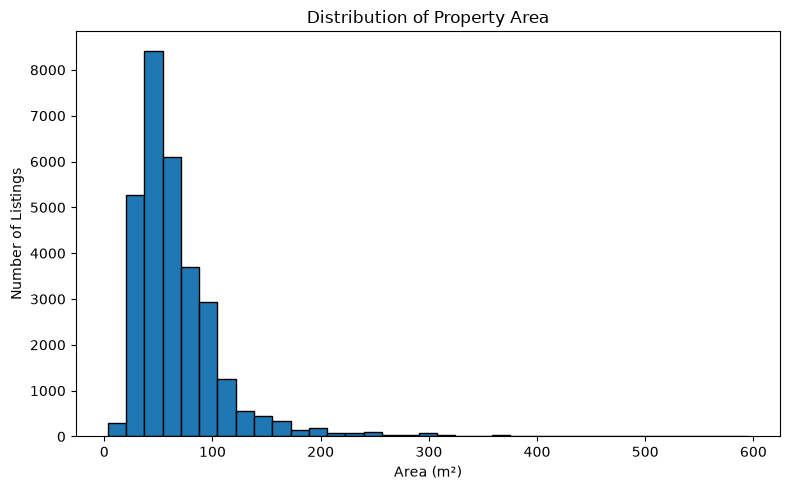

count    30229.000000
mean        68.498741
std         48.069835
min          3.100000
25%         40.000000
50%         56.000000
75%         80.000000
max        595.000000
Name: Area, dtype: float64
Area skewness: 3.8885


In [15]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Area"], bins=35, edgecolor="black")
plt.title("Distribution of Property Area")
plt.xlabel("Area (m²)")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

print(df_clean["Area"].describe())
print("Area skewness:", round(df_clean["Area"].skew(), 4))

### Analysis - Area Distribution

Area is complete for all 30,229 observations. Its median is 56 m², mean is approximately 68.50 m², and maximum is 595 m². Skewness is 3.8885, showing a long right tail caused by a smaller number of large properties.

The large values are not automatically removed: they are positive, plausible property areas and may represent valid listings.

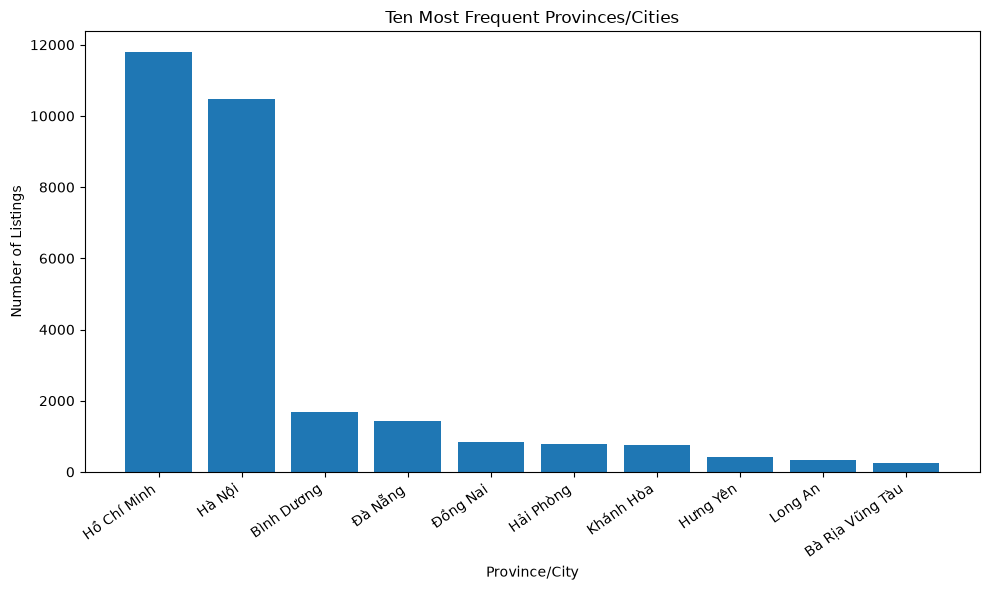

Province
Hồ Chí Minh        11788
Hà Nội             10464
Bình Dương          1673
Đà Nẵng             1437
Đồng Nai             829
Hải Phòng            789
Khánh Hòa            744
Hưng Yên             405
Long An              339
Bà Rịa Vũng Tàu      240


In [16]:
province_counts = df_clean["Province"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.bar(province_counts.index, province_counts.values)
plt.title("Ten Most Frequent Provinces/Cities")
plt.xlabel("Province/City")
plt.ylabel("Number of Listings")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

print(province_counts.to_string())

### Analysis - Province Distribution

The dataset is geographically imbalanced. Hồ Chí Minh and Hà Nội dominate the listings, followed by much smaller groups from Bình Dương, Đà Nẵng, Đồng Nai, Hải Phòng, and other provinces.

Province remains essential because property markets differ by location, but performance for sparsely represented provinces is less certain. OneHotEncoder with handle_unknown="ignore" also allows the Pipeline to receive a province not observed during training without failing.

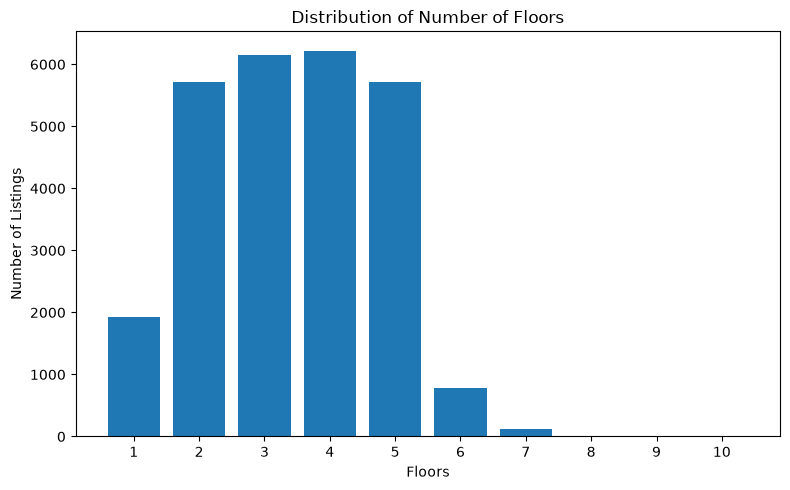

count    26626.000000
mean         3.410426
std          1.328897
min          1.000000
25%          2.000000
50%          3.000000
75%          4.000000
max         10.000000
Name: Floors, dtype: float64


In [17]:
floor_counts = df_clean["Floors"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(floor_counts.index.astype(int).astype(str), floor_counts.values)
plt.title("Distribution of Number of Floors")
plt.xlabel("Floors")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

print(df_clean["Floors"].describe())

### Analysis - Floors Distribution

The median property has 3 floors and the mean is approximately 3.41. Observed values range from 1 to 10 floors, while 11.92% of listings have missing floor information.

The observed distribution is nearly symmetric, but missing values remain in the modeling data and are imputed from training folds only.

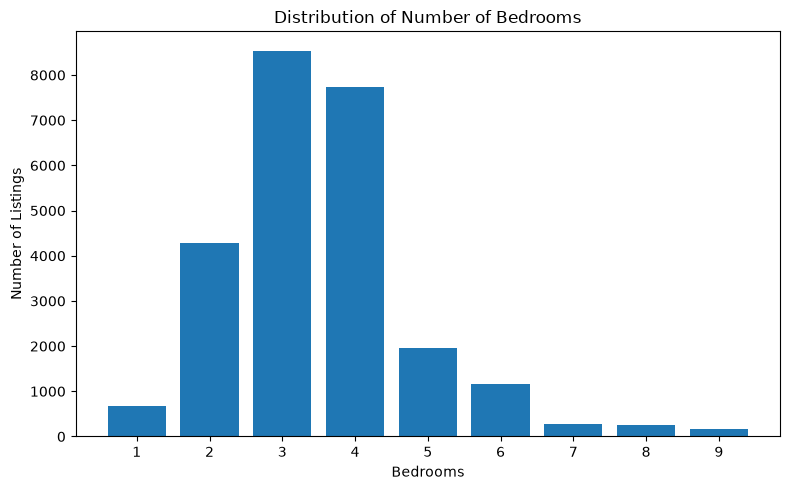

count    25067.000000
mean         3.511030
std          1.309116
min          1.000000
25%          3.000000
50%          3.000000
75%          4.000000
max          9.000000
Name: Bedrooms, dtype: float64


In [18]:
bedroom_counts = df_clean["Bedrooms"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(bedroom_counts.index.astype(int).astype(str), bedroom_counts.values)
plt.title("Distribution of Number of Bedrooms")
plt.xlabel("Bedrooms")
plt.ylabel("Number of Listings")
plt.tight_layout()
plt.show()

print(df_clean["Bedrooms"].describe())

### Analysis - Bedrooms Distribution

The median listing has 3 bedrooms and the mean is approximately 3.51. Observed counts range from 1 to 9, with most listings concentrated between 3 and 4 bedrooms. Bedrooms is missing for 17.08% of observations.

The right tail represents larger-capacity homes and is retained rather than treated as invalid.

## 8. Boxplot and Outlier Analysis

A boxplot is used to examine the strongly skewed Area feature. Boxplot outliers are statistical flags, not automatic evidence of invalid data.

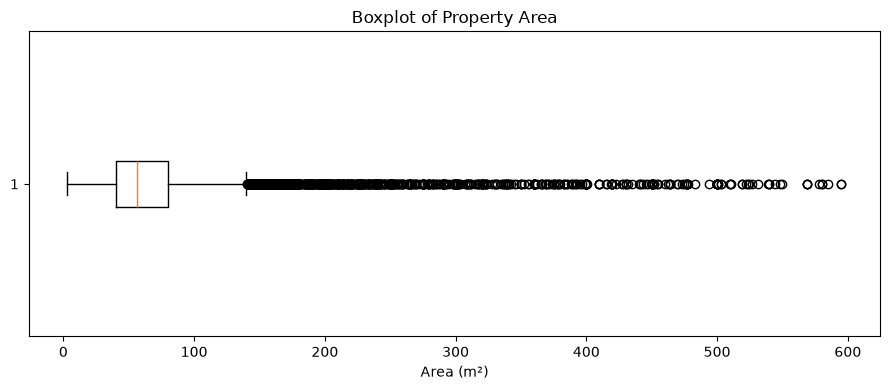

Q1: 40.0
Q3: 80.0
IQR: 40.0
Upper boxplot fence: 140.0
Observations above upper fence: 1636


In [19]:
area_q1 = df_clean["Area"].quantile(0.25)
area_q3 = df_clean["Area"].quantile(0.75)
area_iqr = area_q3 - area_q1
area_upper_fence = area_q3 + 1.5 * area_iqr
area_boxplot_outliers = (df_clean["Area"] > area_upper_fence).sum()

plt.figure(figsize=(9, 4))
plt.boxplot(df_clean["Area"], orientation="horizontal")
plt.title("Boxplot of Property Area")
plt.xlabel("Area (m²)")
plt.tight_layout()
plt.show()

print("Q1:", area_q1)
print("Q3:", area_q3)
print("IQR:", area_iqr)
print("Upper boxplot fence:", area_upper_fence)
print("Observations above upper fence:", area_boxplot_outliers)

### Outlier Analysis

The boxplot confirms a long upper tail beyond the conventional IQR fence. These observations are unusual relative to the central distribution but remain within the positive 3.1–595 m² dataset range and can represent genuinely large properties.

No area observation is removed. Deletion based only on an IQR rule could discard valid market segments and change the prediction task.

## 9. Train/Test Split

The compact six-feature representation is used for the initial model comparison. The test set is held out with a fixed 80/20 split.

Training data supports model fitting and all cross-validation selection. The test set provides descriptive holdout metrics and the final evaluation, but is never used to tune hyperparameters or choose the feature representation.

In [20]:
X = df_clean[selected_features].copy()
y = df_clean[target].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Training target range:", (y_train.min(), y_train.max()))
print("Testing target range:", (y_test.min(), y_test.max()))

Training samples: 24183
Testing samples: 6046
Training target range: (np.float64(1.0), np.float64(11.5))
Testing target range: (np.float64(1.0), np.float64(10.9))


## 10. Preprocessing

Numerical and categorical features require different transformations. A ColumnTransformer keeps every learned preprocessing step inside the model Pipeline.

- Numerical: median imputation, then StandardScaler.
- Categorical: most-frequent imputation, then OneHotEncoder with unknown-category handling.

Dense one-hot output is used because the number of categories is moderate and dense input is substantially more efficient for the tree models in this environment.

In [21]:
def create_preprocessor(numeric_features, categorical_features):
    """Build a fresh preprocessing transformer for a raw feature representation."""
    numeric_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            sparse_output=False
        ))
    ])

    return ColumnTransformer([
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features)
    ])


def create_model_pipeline(model, numeric_features, categorical_features):
    """Combine representation-specific preprocessing with a regressor."""
    return Pipeline([
        ("preprocessor", create_preprocessor(
            numeric_features,
            categorical_features
        )),
        ("model", model)
    ])


selected_preprocessor = create_preprocessor(
    selected_numeric_features,
    selected_categorical_features
)

selected_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``fe

## 11. Baseline Regression

DummyRegressor with strategy="mean" predicts the training-set mean for every property. It establishes a minimum reference before fitting learned regression models.

Five metrics are reported:

- Lower is better for MAE, MSE, RMSE, and MAPE.
- Higher is better for R².
- MAPE is valid because Price contains no zero values. A value of 0.25 corresponds to a 25% average absolute percentage error.

In [22]:
def calculate_regression_metrics(y_true, y_pred):
    """Return regression metrics without rounding their stored values."""
    mse = mean_squared_error(y_true, y_pred)

    if (np.asarray(y_true) == 0).any():
        mape = np.nan
    else:
        mape = mean_absolute_percentage_error(y_true, y_pred)

    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
        "R2": r2_score(y_true, y_pred),
        "MAPE": mape
    }


baseline_model = create_model_pipeline(
    DummyRegressor(strategy="mean"),
    selected_numeric_features,
    selected_categorical_features
)

baseline_model.fit(X_train, y_train)
baseline_pred = baseline_model.predict(X_test)
baseline_metrics = calculate_regression_metrics(y_test, baseline_pred)

print("Baseline metrics:")
print(pd.Series(baseline_metrics).round(4).to_string())

Baseline metrics:
MAE     1.8438
MSE     4.8760
RMSE    2.2082
R2     -0.0000
MAPE    0.4443


### Baseline Analysis

The mean baseline achieves MAE 1.8438, MSE 4.8760, RMSE 2.2082 billion VND, R² approximately 0, and MAPE 0.4443 (44.43%).

Its R² near zero is expected because it does not use property information. The baseline gives a concrete reference that useful learned models should improve upon across several error metrics, not R² alone.

## 12. Main Regression Models

Five standard regressors are compared without prior hyperparameter tuning:

1. Linear Regression
2. K-Nearest Neighbors with n_neighbors=5
3. Decision Tree with random_state=42
4. Random Forest with 100 trees and random_state=42
5. Support Vector Regressor with an RBF kernel

Every regressor receives the same six raw features and its own complete preprocessing Pipeline.

In [23]:
model_estimators = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(n_neighbors=5),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ),
    "SVR": SVR(kernel="rbf")
}

trained_models = {}
holdout_predictions = {}
holdout_results = [{
    "Model": "Baseline",
    **baseline_metrics
}]

for model_name, estimator in model_estimators.items():
    pipeline = create_model_pipeline(
        estimator,
        selected_numeric_features,
        selected_categorical_features
    )
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)

    trained_models[model_name] = pipeline
    holdout_predictions[model_name] = predictions
    holdout_results.append({
        "Model": model_name,
        **calculate_regression_metrics(y_test, predictions)
    })
    print(f"{model_name} trained and evaluated.")

model_comparison_df = pd.DataFrame(holdout_results)

print("\nHoldout model comparison:")
print(model_comparison_df.round(4).to_string(index=False))

Linear Regression trained and evaluated.


KNN trained and evaluated.
Decision Tree trained and evaluated.


Random Forest trained and evaluated.


SVR trained and evaluated.

Holdout model comparison:
            Model    MAE    MSE   RMSE      R2   MAPE
         Baseline 1.8438 4.8760 2.2082 -0.0000 0.4443
Linear Regression 1.4782 3.4039 1.8450  0.3019 0.3293
              KNN 1.3627 3.0777 1.7543  0.3688 0.2931
    Decision Tree 1.3976 3.6669 1.9149  0.2480 0.2947
    Random Forest 1.3009 2.9549 1.7190  0.3940 0.2784
              SVR 1.2868 2.7615 1.6618  0.4336 0.2731


## 13. Holdout Model Comparison

The descriptive holdout results show that all five learned models improve substantially over the mean baseline.

- Linear Regression: RMSE 1.8450, R² 0.3019.
- KNN: RMSE 1.7543, R² 0.3688.
- Decision Tree: RMSE 1.9149, R² 0.2480.
- Random Forest: RMSE 1.7190, R² 0.3940.
- SVR: RMSE 1.6618, R² 0.4336.

SVR has the lowest holdout MAE, MSE, RMSE, and MAPE and the highest R². However, these test results are descriptive and are not used for model or hyperparameter selection; the controlled experiments below use training-only cross-validation.

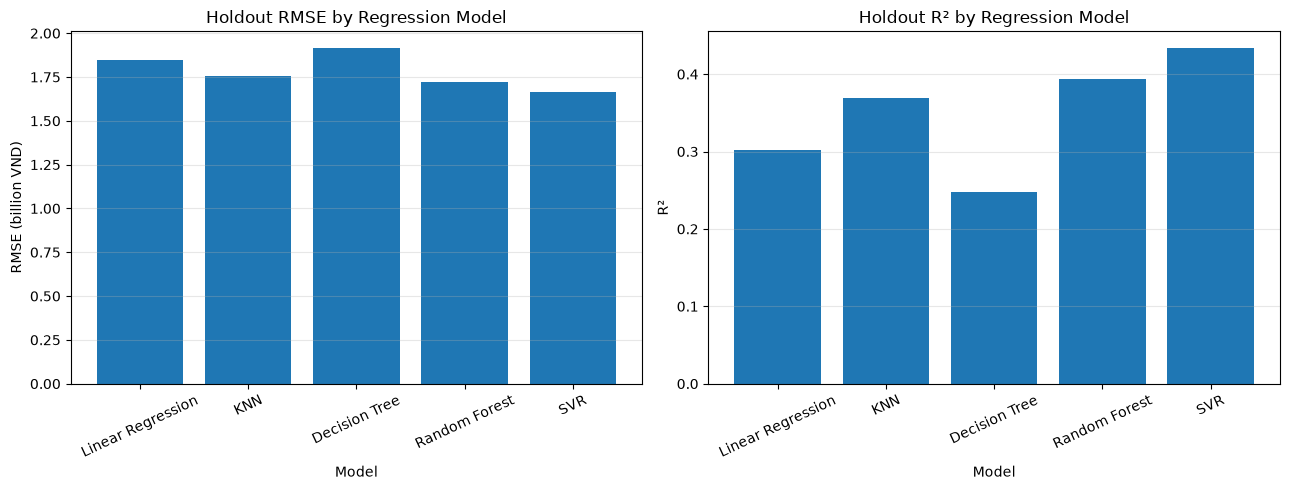

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\model_comparison.png


In [24]:
comparison_models = model_comparison_df[
    model_comparison_df["Model"] != "Baseline"
].copy()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(comparison_models["Model"], comparison_models["RMSE"])
axes[0].set_title("Holdout RMSE by Regression Model")
axes[0].set_xlabel("Model")
axes[0].set_ylabel("RMSE (billion VND)")
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", alpha=0.3)

axes[1].bar(comparison_models["Model"], comparison_models["R2"])
axes[1].set_title("Holdout R² by Regression Model")
axes[1].set_xlabel("Model")
axes[1].set_ylabel("R²")
axes[1].tick_params(axis="x", rotation=25)
axes[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
model_comparison_figure = FIGURE_DIR / "model_comparison.png"
plt.savefig(model_comparison_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", model_comparison_figure)

### Holdout Visualization Analysis

The two panels avoid placing differently scaled metrics on the same axis. Lower RMSE and higher R² both favour SVR on this holdout split, followed by Random Forest.

The ranking is not treated as final evidence because a single split can be sensitive to which observations enter the test set. Training-only five-fold cross-validation is used next.

## 14. Controlled Experiments

### Experiment 1 - Cross-Validation Model Comparison

#### Objective

Compare the five regression algorithms under the same training-only conditions.

#### Controlled Conditions

- Same 24,183 training observations
- Same six raw features
- Same numerical and categorical preprocessing
- Same five shuffled KFold splits with random_state=42
- Same primary metric: RMSE
- No use of the test set

#### Independent Variable

Only the regression algorithm changes.

In [25]:
cv_strategy = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_rmse_scores = {}
experiment_1_results = []

for model_name, estimator in model_estimators.items():
    pipeline = create_model_pipeline(
        estimator,
        selected_numeric_features,
        selected_categorical_features
    )

    negative_rmse = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring="neg_root_mean_squared_error"
    )
    rmse_scores = -negative_rmse

    cv_rmse_scores[model_name] = rmse_scores
    experiment_1_results.append({
        "Model": model_name,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

    print(f"{model_name}: {np.round(rmse_scores, 4)}")

experiment_1_df = (
    pd.DataFrame(experiment_1_results)
    .sort_values("Mean CV RMSE")
    .reset_index(drop=True)
)

print("\nExperiment 1 summary:")
print(experiment_1_df.round(4).to_string(index=False))

Linear Regression: [1.8197 1.8861 1.8344 1.8686 1.8608]


KNN: [1.7478 1.7931 1.7516 1.7405 1.7676]


Decision Tree: [1.9101 2.0076 1.9191 1.9437 1.9022]


Random Forest: [1.7051 1.767  1.6928 1.7076 1.6924]


SVR: [1.6431 1.6781 1.6564 1.6478 1.6573]

Experiment 1 summary:
            Model  Mean CV RMSE  Std CV RMSE
              SVR        1.6565       0.0120
    Random Forest        1.7130       0.0277
              KNN        1.7601       0.0187
Linear Regression        1.8539       0.0239
    Decision Tree        1.9365       0.0381


#### Experiment 1 Results and Conclusion

SVR achieves the lowest mean CV RMSE at 1.6565 billion VND and also the smallest standard deviation, 0.0120. The ranking by mean RMSE is:

1. SVR: 1.6565
2. Random Forest: 1.7130
3. KNN: 1.7601
4. Linear Regression: 1.8539
5. Decision Tree: 1.9365

Therefore, SVR is the strongest of the five original configurations. Random Forest is the strongest tree-based model and remains a reasonable candidate for the controlled depth experiment because it is close to SVR, supports feature importance, and can alter its bias-variance balance through max_depth.

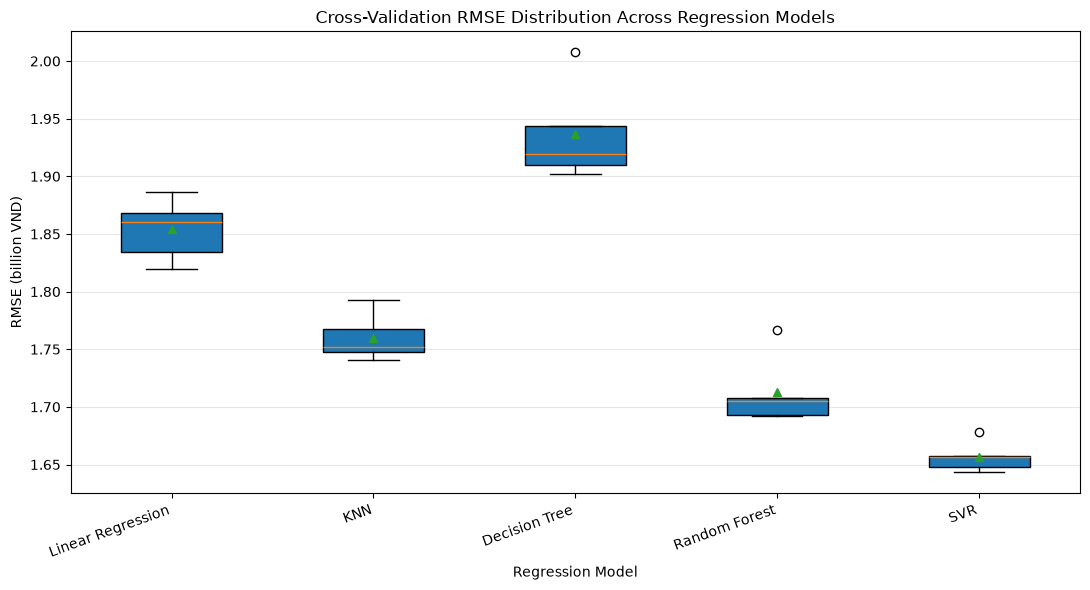

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\model_cv_rmse_boxplot.png


In [26]:
model_names = list(cv_rmse_scores.keys())
rmse_distributions = [cv_rmse_scores[name] for name in model_names]

plt.figure(figsize=(11, 6))
plt.boxplot(
    rmse_distributions,
    tick_labels=model_names,
    patch_artist=True,
    showmeans=True
)
plt.title("Cross-Validation RMSE Distribution Across Regression Models")
plt.xlabel("Regression Model")
plt.ylabel("RMSE (billion VND)")
plt.xticks(rotation=20, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

cv_boxplot_figure = FIGURE_DIR / "model_cv_rmse_boxplot.png"
plt.savefig(cv_boxplot_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", cv_boxplot_figure)

### Cross-Validation Boxplot Analysis

Each box summarizes five training-fold RMSE values. The median line represents the middle fold, while the box and whiskers show fold-to-fold spread. Lower positions are better.

SVR has the lowest and tightest distribution, supporting both performance and stability. Random Forest is second by mean RMSE but varies more across folds. Decision Tree has both the highest mean and the widest weak-performing range among the compared models. Five folds provide useful but still limited evidence, so very small differences should not be overstated.

### Experiment 2 - Random Forest max_depth

#### Objective

Test whether controlling tree depth improves the best tree-based model.

#### Controlled Conditions

- Same six-feature training representation
- Same 100-tree Random Forest
- Same random_state=42
- Same preprocessing
- Same five KFold splits
- Same RMSE metric
- No test-set use

#### Independent Variable

Only max_depth changes: 4, 8, 12, 16, or None. This experiment does not assume that Random Forest must beat SVR.

In [27]:
max_depth_values = [4, 8, 12, 16, None]
experiment_2_scores = {}
experiment_2_results = []

for depth in max_depth_values:
    pipeline = create_model_pipeline(
        RandomForestRegressor(
            n_estimators=100,
            max_depth=depth,
            random_state=42
        ),
        selected_numeric_features,
        selected_categorical_features
    )

    rmse_scores = -cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv_strategy,
        scoring="neg_root_mean_squared_error"
    )

    depth_label = str(depth)
    experiment_2_scores[depth_label] = rmse_scores
    experiment_2_results.append({
        "Hyperparameter": f"max_depth={depth_label}",
        "max_depth": depth_label,
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

experiment_2_df = pd.DataFrame(experiment_2_results)
best_depth_index = experiment_2_df["Mean CV RMSE"].idxmin()
best_depth = experiment_2_df.loc[best_depth_index, "max_depth"]

print(experiment_2_df.round(4).to_string(index=False))
print("\nBest max_depth:", best_depth)

Hyperparameter max_depth  Mean CV RMSE  Std CV RMSE
   max_depth=4         4        1.8191       0.0109
   max_depth=8         8        1.6843       0.0138
  max_depth=12        12        1.6526       0.0189
  max_depth=16        16        1.6683       0.0258
max_depth=None      None        1.7130       0.0277

Best max_depth: 12


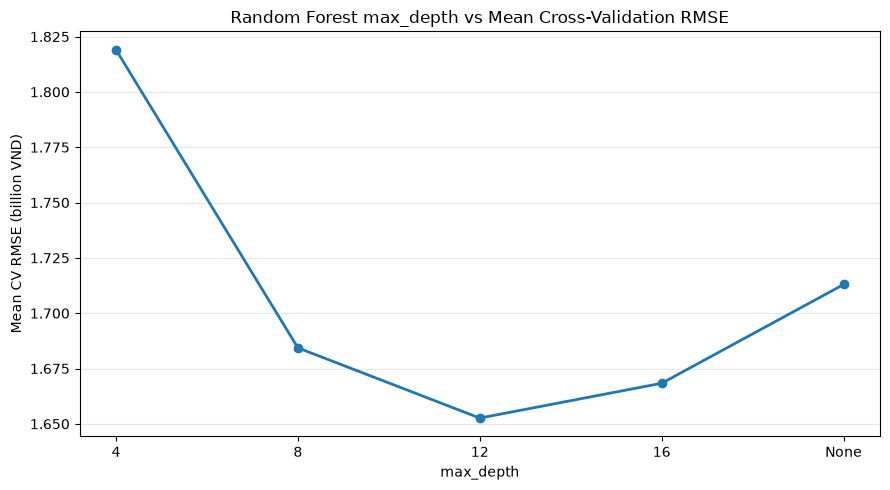

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\experiment_2_hyperparameter.png


In [28]:
plt.figure(figsize=(9, 5))
plt.plot(
    experiment_2_df["max_depth"],
    experiment_2_df["Mean CV RMSE"],
    marker="o",
    linewidth=2
)
plt.title("Random Forest max_depth vs Mean Cross-Validation RMSE")
plt.xlabel("max_depth")
plt.ylabel("Mean CV RMSE (billion VND)")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

experiment_2_figure = FIGURE_DIR / "experiment_2_hyperparameter.png"
plt.savefig(experiment_2_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", experiment_2_figure)

#### Experiment 2 Analysis and Conclusion

Mean CV RMSE decreases from 1.8191 at depth 4 to 1.6843 at depth 8 and reaches its minimum of 1.6526 at depth 12. It then increases to 1.6683 at depth 16 and 1.7130 without a depth limit.

Depth 4 is too restrictive under these conditions and supports an underfitting interpretation. Depth 12 provides the best tested balance. The deterioration for deeper trees is consistent with increased variance, although the experiment does not independently prove overfitting in every tree.

The tuned six-feature Random Forest at depth 12 slightly improves on the original SVR mean CV RMSE of 1.6565, but the difference is only 0.0039 and should be treated as small.

### Experiment 3 - Feature Representation

#### Objective

Compare the required compact six-feature representation with all 11 usable property attributes.

#### Representation A

Province, Area, Floors, Bedrooms, Bathrooms, and Legal status.

#### Representation B

All usable attributes after replacing noisy high-cardinality Address with Province. No target-derived feature is included.

#### Controlled Conditions

- Same training row indices and target values
- Same Random Forest with 100 trees, max_depth=12, random_state=42
- Same numerical/categorical preprocessing concept
- Same five KFold splits
- Same RMSE metric
- Only the raw feature representation changes

In [29]:
all_usable_features = [
    "Province",
    "Area",
    "Frontage",
    "Access Road",
    "House direction",
    "Balcony direction",
    "Floors",
    "Bedrooms",
    "Bathrooms",
    "Legal status",
    "Furniture state"
]

all_numeric_features = [
    "Area",
    "Frontage",
    "Access Road",
    "Floors",
    "Bedrooms",
    "Bathrooms"
]

all_categorical_features = [
    "Province",
    "House direction",
    "Balcony direction",
    "Legal status",
    "Furniture state"
]

X_train_6 = df_clean.loc[X_train.index, selected_features]
X_train_11 = df_clean.loc[X_train.index, all_usable_features]

representation_definitions = [
    (
        "Selected 6 features",
        X_train_6,
        selected_numeric_features,
        selected_categorical_features
    ),
    (
        "All usable 11 features",
        X_train_11,
        all_numeric_features,
        all_categorical_features
    )
]

experiment_3_scores = {}
experiment_3_results = []

for representation_name, X_representation, numeric_representation, categorical_representation in representation_definitions:
    pipeline = create_model_pipeline(
        RandomForestRegressor(
            n_estimators=100,
            max_depth=12,
            random_state=42
        ),
        numeric_representation,
        categorical_representation
    )

    rmse_scores = -cross_val_score(
        pipeline,
        X_representation,
        y_train,
        cv=cv_strategy,
        scoring="neg_root_mean_squared_error"
    )

    experiment_3_scores[representation_name] = rmse_scores
    experiment_3_results.append({
        "Representation": representation_name,
        "Number of Raw Features": X_representation.shape[1],
        "Mean CV RMSE": rmse_scores.mean(),
        "Std CV RMSE": rmse_scores.std()
    })

    print(f"{representation_name}: {np.round(rmse_scores, 4)}")

experiment_3_df = pd.DataFrame(experiment_3_results)

print("\nExperiment 3 summary:")
print(experiment_3_df.round(4).to_string(index=False))

Selected 6 features: [1.6372 1.6894 1.6402 1.6473 1.649 ]


All usable 11 features: [1.5814 1.6466 1.5925 1.5983 1.6201]

Experiment 3 summary:
        Representation  Number of Raw Features  Mean CV RMSE  Std CV RMSE
   Selected 6 features                       6        1.6526       0.0189
All usable 11 features                      11        1.6078       0.0231


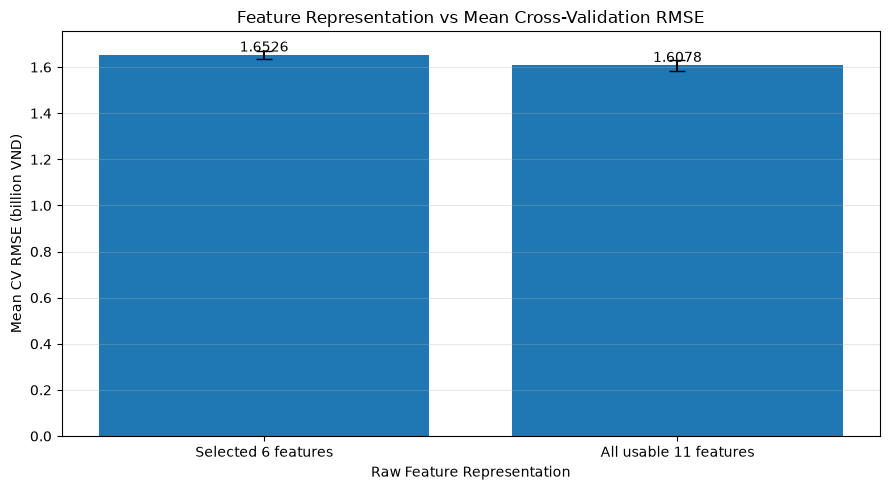

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\experiment_3_feature_representation.png


In [30]:
plt.figure(figsize=(9, 5))
bars = plt.bar(
    experiment_3_df["Representation"],
    experiment_3_df["Mean CV RMSE"],
    yerr=experiment_3_df["Std CV RMSE"],
    capsize=6
)
plt.title("Feature Representation vs Mean Cross-Validation RMSE")
plt.xlabel("Raw Feature Representation")
plt.ylabel("Mean CV RMSE (billion VND)")
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, experiment_3_df["Mean CV RMSE"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.015,
        f"{value:.4f}",
        ha="center"
    )

plt.tight_layout()
experiment_3_figure = FIGURE_DIR / "experiment_3_feature_representation.png"
plt.savefig(experiment_3_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", experiment_3_figure)

#### Experiment 3 Results, Analysis, and Conclusion

The selected six-feature representation achieves mean CV RMSE 1.6526 with standard deviation 0.0189. The all-usable representation achieves a lower mean RMSE of 1.6078 with standard deviation 0.0231.

Adding Frontage, Access Road, both direction fields, and Furniture state reduces mean RMSE by approximately 0.0448 billion VND despite their missingness. Pipeline imputation allows the model to use their available information without dropping rows.

Representation B is selected for the final model because it provides the best training-only CV result. Its fold variability is slightly higher, and the gain is modest relative to the target scale, so the compact six-feature representation remains a defensible lower-input alternative rather than being declared useless.

## 15. Final Model Selection

The final configuration is selected exclusively from training cross-validation evidence:

- **Algorithm:** Random Forest Regressor
- **Raw representation:** all 11 usable features
- **Hyperparameters:** n_estimators=100, max_depth=12, random_state=42
- **Numerical preprocessing:** median imputation and standardization
- **Categorical preprocessing:** most-frequent imputation and one-hot encoding with unknown-category handling
- **Target scale:** original Price in billions of VND

The five-model comparison initially favoured SVR at CV RMSE 1.6565. Experiment 2 found a tuned six-feature Random Forest at 1.6526, and Experiment 3 improved the same tuned model to 1.6078 with all usable features. This configuration is therefore the best observed training-CV candidate.

The held-out test metrics seen earlier are not used to alter this choice.

## 16. Final Test Evaluation

After selection, a fresh final Pipeline is fitted on the 24,183 training rows using the chosen 11-feature representation. The held-out test representation uses the same original row indices and column order.

In [31]:
final_features = all_usable_features.copy()
final_numeric_features = all_numeric_features.copy()
final_categorical_features = all_categorical_features.copy()

X_train_final = df_clean.loc[X_train.index, final_features]
X_test_final = df_clean.loc[X_test.index, final_features]

final_model = create_model_pipeline(
    RandomForestRegressor(
        n_estimators=100,
        max_depth=12,
        random_state=42
    ),
    final_numeric_features,
    final_categorical_features
)

final_model.fit(X_train_final, y_train)
final_pred = final_model.predict(X_test_final)
final_metrics = calculate_regression_metrics(y_test, final_pred)

final_metrics_df = pd.DataFrame({
    "Metric": list(final_metrics.keys()),
    "Score": list(final_metrics.values())
})

print("Final test metrics:")
print(final_metrics_df.round(4).to_string(index=False))
print("\nFinal MAPE percentage:", f"{final_metrics['MAPE'] * 100:.2f}%")

Final test metrics:
Metric  Score
   MAE 1.2529
   MSE 2.5659
  RMSE 1.6018
    R2 0.4738
  MAPE 0.2736

Final MAPE percentage: 27.36%


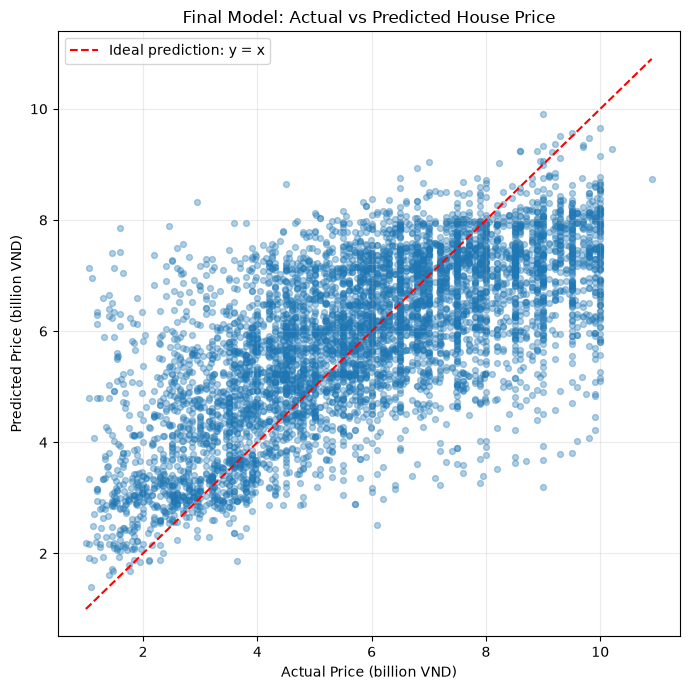

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\final_actual_vs_predicted.png


In [32]:
actual_min = min(y_test.min(), final_pred.min())
actual_max = max(y_test.max(), final_pred.max())

plt.figure(figsize=(7, 7))
plt.scatter(y_test, final_pred, alpha=0.35, s=18)
plt.plot(
    [actual_min, actual_max],
    [actual_min, actual_max],
    linestyle="--",
    color="red",
    label="Ideal prediction: y = x"
)
plt.title("Final Model: Actual vs Predicted House Price")
plt.xlabel("Actual Price (billion VND)")
plt.ylabel("Predicted Price (billion VND)")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

actual_predicted_figure = FIGURE_DIR / "final_actual_vs_predicted.png"
plt.savefig(actual_predicted_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", actual_predicted_figure)

### Final Test Analysis

The selected Pipeline achieves:

- MAE: 1.2529 billion VND
- MSE: 2.5659 (billion VND)²
- RMSE: 1.6018 billion VND
- R²: 0.4738
- MAPE: 0.2736, or 27.36%

R² indicates that the model explains approximately 47.38% of test-set price variance, while the absolute-error metrics show that substantial listing-level uncertainty remains. The scatter generally follows the y=x direction but is widely dispersed. Predictions occupy a narrower range than actual prices, which is consistent with regression toward the centre of the training distribution.

The result is an academic evaluation, not evidence of professional valuation accuracy.

## 17. Residual Analysis

Residuals are defined as:

residual = actual price - predicted price

Positive residuals indicate underprediction; negative residuals indicate overprediction.

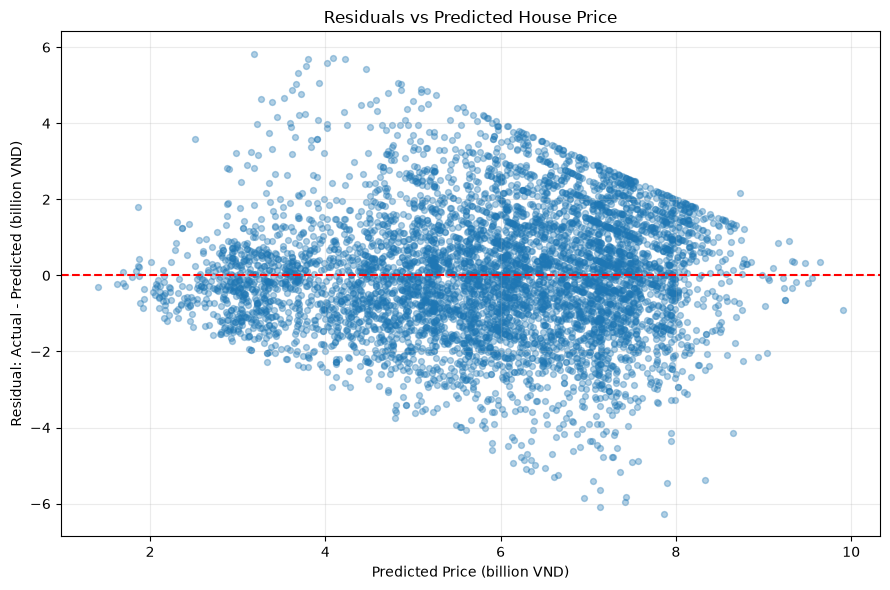

Mean Residual                 -0.0255
Median Residual               -0.0803
Residual Standard Deviation    1.6016
Minimum Residual              -6.2601
Maximum Residual               5.8129
Correlation with Prediction    0.0189

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\final_residual_plot.png


In [33]:
final_residuals = y_test.to_numpy() - final_pred

plt.figure(figsize=(9, 6))
plt.scatter(final_pred, final_residuals, alpha=0.35, s=18)
plt.axhline(0, color="red", linestyle="--")
plt.title("Residuals vs Predicted House Price")
plt.xlabel("Predicted Price (billion VND)")
plt.ylabel("Residual: Actual - Predicted (billion VND)")
plt.grid(alpha=0.25)
plt.tight_layout()

residual_figure = FIGURE_DIR / "final_residual_plot.png"
plt.savefig(residual_figure, dpi=150, bbox_inches="tight")
plt.show()

residual_summary = pd.Series({
    "Mean Residual": final_residuals.mean(),
    "Median Residual": np.median(final_residuals),
    "Residual Standard Deviation": final_residuals.std(),
    "Minimum Residual": final_residuals.min(),
    "Maximum Residual": final_residuals.max(),
    "Correlation with Prediction": np.corrcoef(final_pred, final_residuals)[0, 1]
})

print(residual_summary.round(4).to_string())
print("\nFigure saved to:", residual_figure)

### Residual Analysis

The mean residual is -0.0255 billion VND and the correlation between residuals and predictions is 0.0189, both close to zero. This indicates little overall signed bias and no strong linear residual trend with the predicted value. It does not imply that the errors are randomly distributed.

However, the residual standard deviation is approximately 1.6016 billion VND, with individual residuals from about -6.26 to +5.81 billion VND. The visible wedge/banding and changing vertical spread show that error magnitude is not constant across predicted prices. Large errors remain across the range. The plot is used for descriptive error analysis only; it does not by itself verify every statistical assumption of the model.

## 18. Encoded Feature Importance

The final Random Forest supports impurity-based feature_importances_. Because categorical raw features expand through one-hot encoding, importance is reported for transformed model columns.

The notebook does not incorrectly merge encoded columns back into raw features. Only the top 20 encoded columns are visualized for readability.

                           Encoded Feature  Importance
                             numeric__Area      0.2856
                        numeric__Bathrooms      0.2226
                           numeric__Floors      0.1094
                      numeric__Access Road      0.0770
         categorical__Province_Hồ Chí Minh      0.0676
                         numeric__Frontage      0.0441
              categorical__Province_Hà Nội      0.0340
                         numeric__Bedrooms      0.0260
           categorical__Province_Hải Phòng      0.0218
          categorical__Province_Bình Dương      0.0183
             categorical__Province_Long An      0.0108
             categorical__Province_Đà Nẵng      0.0085
            categorical__Province_Hưng Yên      0.0060
        categorical__Furniture state_Basic      0.0056
         categorical__Furniture state_Full      0.0051
   categorical__House direction_Đông - Nam      0.0050
   categorical__Legal status_Sale contract      0.0039
categorica

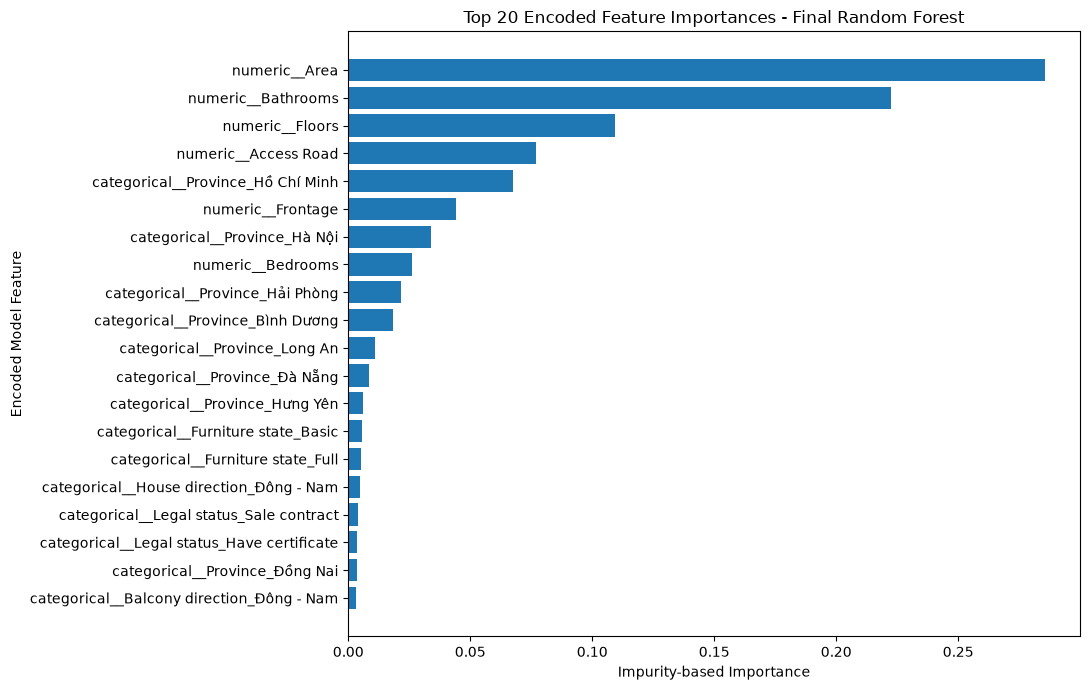

Figure saved to: E:\WINDOW\Project\intelligent-system-assignment-01\figures\house_price\final_feature_importance.png


In [34]:
transformed_feature_names = (
    final_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance_df = (
    pd.DataFrame({
        "Encoded Feature": transformed_feature_names,
        "Importance": final_model.named_steps["model"].feature_importances_
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)

top_feature_importance_df = feature_importance_df.head(20)
print(top_feature_importance_df.round(4).to_string(index=False))

plot_importance_df = top_feature_importance_df.sort_values("Importance")

plt.figure(figsize=(11, 7))
plt.barh(
    plot_importance_df["Encoded Feature"],
    plot_importance_df["Importance"]
)
plt.title("Top 20 Encoded Feature Importances - Final Random Forest")
plt.xlabel("Impurity-based Importance")
plt.ylabel("Encoded Model Feature")
plt.tight_layout()

feature_importance_figure = FIGURE_DIR / "final_feature_importance.png"
plt.savefig(feature_importance_figure, dpi=150, bbox_inches="tight")
plt.show()

print("Figure saved to:", feature_importance_figure)

### Feature Importance Analysis

The strongest encoded features are numeric Area (0.2856), Bathrooms (0.2226), Floors (0.1094), Access Road (0.0770), and the Hồ Chí Minh Province indicator (0.0676). Frontage and the Hà Nội, Hải Phòng, Bình Dương, and Long An indicators also appear among the leading features.

These are model-specific impurity importances. They do not establish causal effects, and importance can be distributed across correlated or related encoded columns. Location categories with few observations should be interpreted particularly cautiously.

## 19. Intelligent System Demonstration

Three synthetic property cases use the final **raw 11-feature representation**. Values and categories are within ranges observed in the dataset. The examples are not copied from held-out rows, and no manual preprocessing is applied outside final_model.

In [35]:
demo_cases = pd.DataFrame([
    {
        "Province": "Hồ Chí Minh",
        "Area": 45.0,
        "Frontage": 4.0,
        "Access Road": 4.0,
        "House direction": "Đông - Nam",
        "Balcony direction": "Đông - Nam",
        "Floors": 3.0,
        "Bedrooms": 3.0,
        "Bathrooms": 3.0,
        "Legal status": "Have certificate",
        "Furniture state": "Full"
    },
    {
        "Province": "Bình Dương",
        "Area": 80.0,
        "Frontage": 5.0,
        "Access Road": 8.0,
        "House direction": "Nam",
        "Balcony direction": "Nam",
        "Floors": 2.0,
        "Bedrooms": 3.0,
        "Bathrooms": 2.0,
        "Legal status": "Have certificate",
        "Furniture state": "Basic"
    },
    {
        "Province": "Hưng Yên",
        "Area": 90.0,
        "Frontage": 6.0,
        "Access Road": 13.0,
        "House direction": "Đông - Bắc",
        "Balcony direction": "Đông - Bắc",
        "Floors": 5.0,
        "Bedrooms": 5.0,
        "Bathrooms": 5.0,
        "Legal status": "Sale contract",
        "Furniture state": "Full"
    }
], index=["Case 1", "Case 2", "Case 3"], columns=final_features)

demo_predictions = final_model.predict(demo_cases)

demo_input_summaries = [
    (
        f"{row['Province']}; {row['Area']:.0f} m²; "
        f"{row['Floors']:.0f} floors; {row['Bedrooms']:.0f} bedrooms; "
        f"{row['Bathrooms']:.0f} bathrooms"
    )
    for _, row in demo_cases.iterrows()
]

demo_results = pd.DataFrame({
    "Case": demo_cases.index,
    "Input Summary": demo_input_summaries,
    "Predicted Price (billion VND)": demo_predictions,
    "Formatted Predicted Price": [
        f"{prediction:.2f} billion VND"
        for prediction in demo_predictions
    ]
})

print("Demo input cases:")
print(demo_cases.to_string())
print("\nDemo predictions:")
print(demo_results.round({"Predicted Price (billion VND)": 4}).to_string(index=False))

Demo input cases:
           Province  Area  Frontage  Access Road House direction Balcony direction  Floors  Bedrooms  Bathrooms      Legal status Furniture state
Case 1  Hồ Chí Minh  45.0       4.0          4.0      Đông - Nam        Đông - Nam     3.0       3.0        3.0  Have certificate            Full
Case 2   Bình Dương  80.0       5.0          8.0             Nam               Nam     2.0       3.0        2.0  Have certificate           Basic
Case 3     Hưng Yên  90.0       6.0         13.0      Đông - Bắc        Đông - Bắc     5.0       5.0        5.0     Sale contract            Full

Demo predictions:
  Case                                         Input Summary  Predicted Price (billion VND) Formatted Predicted Price
Case 1 Hồ Chí Minh; 45 m²; 3 floors; 3 bedrooms; 3 bathrooms                         5.1267          5.13 billion VND
Case 2  Bình Dương; 80 m²; 2 floors; 3 bedrooms; 2 bathrooms                         3.0945          3.09 billion VND
Case 3    Hưng Yên; 90 m²

The three predicted prices are approximately 5.13, 3.09, and 8.62 billion VND. These cases demonstrate that the complete Pipeline accepts raw numeric/categorical fields and produces original-scale outputs.

They are educational examples, not offers, appraisals, investment advice, or professional property valuations.

### Saving and Reloading the Final Pipeline

The complete fitted Pipeline is saved, including numerical imputation, scaling, categorical imputation, one-hot encoding, and the Random Forest regressor.

In [36]:
MODEL_PATH = MODEL_DIR / "house_price_model.joblib"

joblib.dump(final_model, MODEL_PATH)

print("Model saved to:", MODEL_PATH)
print("Model file exists:", MODEL_PATH.exists())

loaded_model = joblib.load(MODEL_PATH)
loaded_demo_predictions = loaded_model.predict(demo_cases)

print("Loaded-model demo predictions:", loaded_demo_predictions)
print(
    "Loaded predictions match original predictions:",
    np.allclose(loaded_demo_predictions, demo_predictions)
)

Model saved to: E:\WINDOW\Project\intelligent-system-assignment-01\models\house_price\house_price_model.joblib
Model file exists: True
Loaded-model demo predictions: [5.12666185 3.09445438 8.61888879]
Loaded predictions match original predictions: True


## 20. Final Intelligent System Pipeline

```text
Property Input
      ↓
Raw Feature Representation
      ↓
Missing / Invalid Value Handling
      ↓
Numerical and Categorical Preprocessing
      ↓
Random Forest Regression Model
      ↓
Predicted House Price
      ↓
Web / Mobile Application
```

A **raw feature** is an interpretable input such as Area, Province, or Legal status. An **encoded feature** is a derived numerical column such as categorical__Province_Hà Nội created by OneHotEncoder. The **model input** is the complete transformed numerical matrix after imputation, scaling, and encoding.

Therefore:

Raw feature ≠ encoded feature ≠ preprocessed model input.

The saved Pipeline preserves the learned preprocessing and estimator together. Province is deterministically derived from Address during dataset preparation; a future interface can request Province directly or apply the same extraction rule before calling the Pipeline.

## 21. Reflection and Limitations

1. **Representation matters.** Experiment 3 reduced CV RMSE from 1.6526 to 1.6078 when the compact six-feature vector was expanded to all 11 usable attributes.
2. **Missing-data handling matters.** Several attributes have high missingness. Pipeline imputation retains rows and prevents medians or modes from being learned from validation/test observations.
3. **Categorical encoding must preserve meaning.** One-hot encoding avoids an unsupported ordinal relationship between provinces, directions, legal states, or furniture states.
4. **Address parsing is imperfect.** Province extraction reduces cardinality, but rare aliases and noisy address endings show that production-quality geocoding would be preferable.
5. **Outliers are not automatically errors.** Large properties can be valid. Removing them solely from a boxplot rule would change the market represented by the data.
6. **The baseline is essential.** It shows whether a learned model improves meaningfully over predicting the training mean.
7. **Algorithms behave differently.** Linear, neighbour-based, single-tree, ensemble, and kernel models produced materially different RMSE and R² results.
8. **Hyperparameters affect complexity.** Depth 4 underfit, depth 12 performed best, and deeper forests increased CV RMSE under the controlled conditions.
9. **The test set should remain unseen for selection.** All algorithm, depth, and representation choices were made from training-only CV; test results evaluate rather than tune the chosen system.
10. **The dataset is geographically imbalanced.** Hồ Chí Minh and Hà Nội dominate, so accuracy for sparsely represented provinces is uncertain.
11. **Time coverage is limited.** The dataset represents listings collected for the 2024 dataset and cannot automatically reflect later market changes.
12. **Listed prices are not necessarily transaction values.** The target may contain seller expectations and platform-specific collection effects.
13. **Prediction errors have practical implications.** An RMSE around 1.60 billion VND is large for many buyers and properties, so individual estimates require caution.
14. **This is an educational system.** It is not a certified appraisal tool or professional property valuation service.
15. **Future improvements** include larger and fresher datasets, more precise district/ward context, economic and interest-rate variables, geospatial coordinates, external validation, more systematic nested tuning, robust uncertainty estimates, and deeper interpretability analysis.

## 22. Reproducibility

The train/test split, shuffled KFold strategy, Decision Tree, and Random Forest use random_state=42 where supported. Model-selection preprocessing is fitted independently inside every cross-validation fold.

In [37]:
version_information = pd.Series({
    "Python": platform.python_version(),
    "pandas": pd.__version__,
    "numpy": np.__version__,
    "matplotlib": matplotlib.__version__,
    "scikit-learn": sklearn.__version__,
    "joblib": joblib.__version__
}, name="Version")

print(version_information.to_string())
print("\nReproducibility random_state: 42")

Python          3.12.0
pandas           3.0.5
numpy            2.5.2
matplotlib      3.11.1
scikit-learn     1.9.0
joblib           1.5.3

Reproducibility random_state: 42
